In [1]:

from scipy.integrate import odeint
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from matplotlib import pyplot as plt, cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp
import numpy as np
from matplotlib.animation import FuncAnimation
from scipy.optimize import curve_fit

import sys



Delta = 0.005
(201, 201)


Text(0.5, 1.0, 'Magnetic Field (Tesla)')

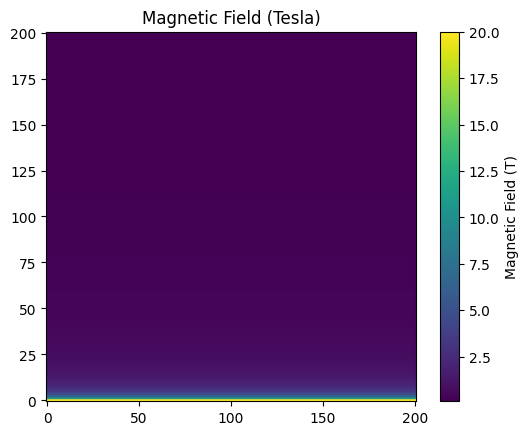

In [2]:
#set up grid
nx,ny = 200,200
x = np.linspace(0, nx, nx + 1)
y = np.linspace(0, ny, ny + 1)
X, Y = np.meshgrid(x, y)
L = 1
delta = L/nx
print("Delta = " + str(delta))

epsilon = 8.85e-12 #F/m
c = 3e8 #m/s
mu = 4e-7*np.pi #H/m or T·m/A
current = 500000; #Amp

#magnetic field
B = np.zeros([nx+1,ny+1],float)
B_1 = np.zeros([nx+1],float)
r = np.zeros([nx+1],float)

for i in range(nx+1):
    for j in range(0,ny+1):
        B[i,j] = mu*current/(2*np.pi*(i+1)*delta)  #Tesla
        B_1[i] = mu*current/(2*np.pi*(i+1)*delta)  #Tesla
        r[i] = (i+1)*delta


print (B.shape)
plt.imshow(B, origin = 'lower', cmap='viridis')
plt.colorbar(label = 'Magnetic Field (T)')
#plt.contour(X, Y, B, levels=20, cmap='Blues')
plt.title('Magnetic Field (Tesla)')


In [3]:
#set up initial potential with 2 conducting surfaces
line_charge = 1e-6 #C/m
constant = line_charge/ (2 * np.pi * epsilon)
inner_radius = 25 #index
phi_ori = np.zeros([nx+1,ny+1],float)
phi_ori[nx,:] = 0
delta_phi = constant * np.log(nx/inner_radius)
phi_ori[inner_radius,:] = delta_phi
print("Delta Phi = " + str(delta_phi))

Delta Phi = 37395.86443265281


37395.86443265281


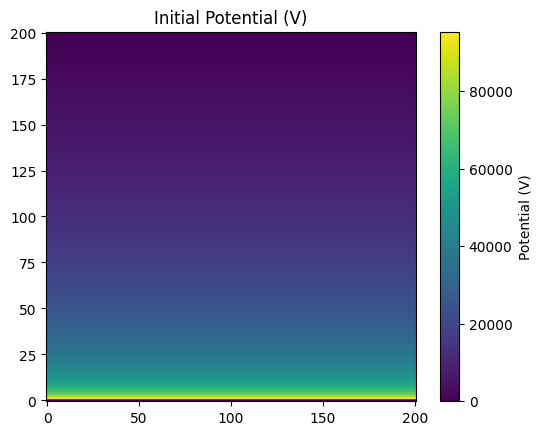

In [4]:
#potential plot without charge density
conductor = 25
for i in range(1,nx+1):
    for j in range(0,ny+1):
        phi_ori[i,j] = constant * np.log(nx/i)

plt.imshow(phi_ori, origin = 'lower')
plt.colorbar(label = 'Potential (V)')
#plt.contour(X, Y, phi_ori, levels=20, cmap='Blues')

plt.title('Initial Potential (V)')
print(phi_ori[inner_radius,60] )

[[-4.          1.5         0.         ...  0.          0.
   0.        ]
 [ 0.5        -4.          1.25       ...  0.          0.
   0.        ]
 [ 0.          0.75       -4.         ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ... -4.          1.00253807
   0.        ]
 [ 0.          0.          0.         ...  0.99746193 -4.
   1.00252525]
 [ 0.          0.          0.         ...  0.          0.99747475
  -4.        ]]


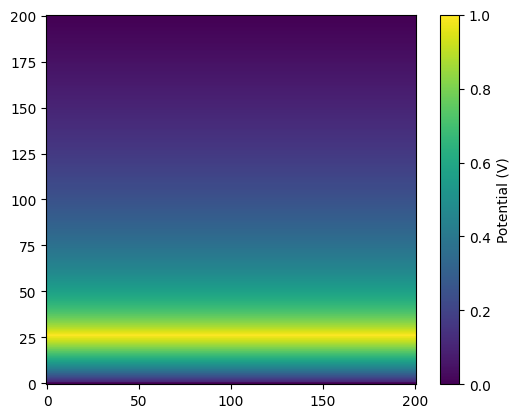

In [5]:
nx, ny = 200, 200
row, col = nx-1,ny+1
conductor = 25

def create_A(row, col):
    num_diag = row*col
    diag = np.full(num_diag, -4.0)
    lower = np.full((num_diag-1),1.0)
    upper = np.full((num_diag-1),1.0)
    identity_up = np.full(num_diag-(nx-1),1.0)
    identity_down = np.full(num_diag-(nx-1),1.0)
    side_up = np.full(row,1.0)
    side_down = np.full(row,1.0)
    
    for i in range(num_diag-1):
        physical_row = (i % row + 1)* delta
        upper[i] = 1.0+ delta/(2.0*physical_row)
        lower[i] = 1.0- delta/(2.0*physical_row)
 

    lower[nx-2::row] = 0.0
    upper[nx-2::row] = 0.0
  
    diag[conductor::row] = 1.0
    lower[conductor-1::row] = 0.0
    upper[conductor::row] = 0.0
    identity_up[(conductor)::row] = 0.0
    identity_down[(conductor)::row] = 0.0
    side_up[(conductor)] = 0.0
    side_down[(conductor)] = 0.0

    diagonal = [diag,lower,upper,identity_down,identity_up,side_down,side_up]
    offsets = [0,-1,1,-(nx-1),(nx-1),-nx*(nx-1),nx*(nx-1)]

    return diags(diagonal, offsets, shape =(num_diag, num_diag), format= 'csr')


# trial 2: including periodic side boundary
# https://my.ece.utah.edu/~ece6340/LECTURES/Feb1/Nagel%202012%20-%20Solving%20the%20Generalized%20Poisson%20Equation%20using%20FDM.pdf
# Matrix inversion method: instantaneous Poisson's solver


#construct boundary vector B
def create_B(rho):
    boundary_conductor = np.zeros(((nx-1)*(ny+1),1),float)
    charge_density = rho[1:nx,0:ny+1].reshape((nx-1)*(ny+1),1,order = 'F')*delta**2*(-1)/epsilon
    boundary_conductor.reshape((nx-1)*(ny+1),1,order = 'F')
    boundary_conductor[conductor::row] += 1
    #boundary_conductor[0::nx-1] = 0
 
    #lil_B2[0:(nx+1)*(ny-1):(ny-1)] = -rho[0,0:nx+1].reshape((ny+1),1)
    #lil_B2[ny-2:(nx+1)*(ny-1):(ny-1)] = -rho[ny,0:nx+1].reshape(ny+1,1)

    return charge_density +boundary_conductor



def solve_poisson_1(rho):
    phi = np.zeros([nx+1,ny+1],float)
    A = create_A(row,col)
    B = create_B(rho)
    phi_flat = phi[1:nx,0:ny+1].flatten(order= 'F') 
    phi_flat= spsolve(A,B)
    phi[1:nx,0:ny+1] = phi_flat.reshape(nx-1,ny+1,order = 'F')
    return phi


A = create_A(row, col).toarray()
print(A)

rho = np.zeros([nx+1,ny+1],float)
phi = solve_poisson_1(rho)
plt.imshow(phi, origin = 'lower')
plt.colorbar(label = 'Potential (V)')
#plt.contour(X, Y, phi, levels=20, cmap='Blues')

In [6]:
def total_potential(phi_ori, rho):
    phi = solve_poisson_1(rho) + phi_ori
    return phi

def electric_field(phi):
    Ex = np.zeros([nx+1, ny+1], float)
    Ey = np.zeros([nx+1, ny+1], float)

    for i in range(0,nx+1):
        for j in range(0,ny+1):

    #for i in range(1, nx):
    #    for j in range(1, ny):
            #Gemini pointed out how 2D-array indexing works as below:
            #row of an array is 'i' (y-direction)
            #column of an array is 'j' (x-direction)
            Ex[i, j] = -(phi[i, (j + 1)%(nx+1)] - phi[i, (j - 1)%(nx+1)]) / (2*delta)
            Ey[i, j] = -(phi[(i + 1)%(ny+1), j] - phi[(i - 1)%(ny+1), j]) / (2*delta)


    plt.show()
    return Ex, Ey

def velocity(Ex, Ey, B):
    vx = np.zeros([nx+1, ny+1], float)
    vy = np.zeros([nx+1, ny+1], float)

    for i in range(0,nx+1):
        for j in range(0,ny+1):

   # for i in range(1, nx):
    #    for j in range(1, ny):
            vx[i, j] = Ey[i, j] / B[i, j]
            vy[i, j] = -Ex[i, j] / B[i, j]  

    return vx, vy


def solve_continuity(rho, vx, vy, dt):
    for n in range (1):
        rho_new = rho.copy()
        for i in range (1,nx):
            for j in range (ny+1):
                #Gemini helped me debug the indexing issue (out of bounds): keep grounding boundaries fixed and updating the sides only by wrapping around
                #Google how negative indexing works in Python
                rho[i,j] = rho_new[i,j] - dt*( (rho_new[i+1,j]-rho_new[i-1,j])*vy[i,j]/(2*delta) + 
                                                   (rho_new[i,(j+1)%(ny+1)]-rho_new[i,(j-1)%(ny+1)])*vx[i,j]/(2*delta) )

        rho[0,:] = 0
        rho[nx,:]=0
    return rho



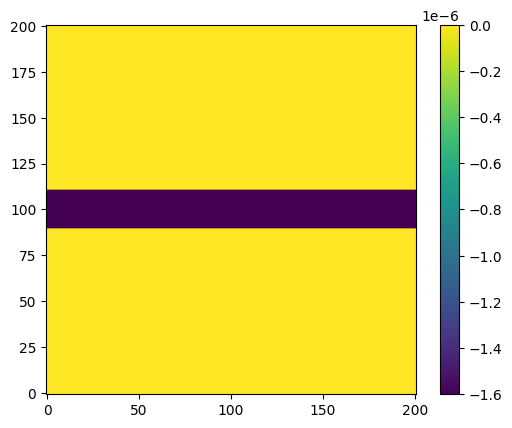

Time step 0
Total charge = -0.006753600000286224
Time step 5
Total charge = -0.006753600000285999
Time step 10
Total charge = -0.006829351528232792
Time step 15
Total charge = 1.050347412766318e+149


/tmp/ipykernel_19375/4153862629.py:46: RuntimeWarning: overflow encountered in scalar divide
  rho[i,j] = rho_new[i,j] - dt*( (rho_new[i+1,j]-rho_new[i-1,j])*vy[i,j]/(2*delta) +
/tmp/ipykernel_19375/4153862629.py:47: RuntimeWarning: overflow encountered in scalar divide
  (rho_new[i,(j+1)%(ny+1)]-rho_new[i,(j-1)%(ny+1)])*vx[i,j]/(2*delta) )
/tmp/ipykernel_19375/4153862629.py:46: RuntimeWarning: invalid value encountered in scalar add
  rho[i,j] = rho_new[i,j] - dt*( (rho_new[i+1,j]-rho_new[i-1,j])*vy[i,j]/(2*delta) +
/tmp/ipykernel_19375/4153862629.py:46: RuntimeWarning: overflow encountered in scalar multiply
  rho[i,j] = rho_new[i,j] - dt*( (rho_new[i+1,j]-rho_new[i-1,j])*vy[i,j]/(2*delta) +
/tmp/ipykernel_19375/4153862629.py:47: RuntimeWarning: overflow encountered in scalar multiply
  (rho_new[i,(j+1)%(ny+1)]-rho_new[i,(j-1)%(ny+1)])*vx[i,j]/(2*delta) )
/tmp/ipykernel_19375/4153862629.py:46: RuntimeWarning: overflow encountered in scalar add
  rho[i,j] = rho_new[i,j] - dt*( (rho_ne

Simulation saved.
Saving animation... This may take a moment.


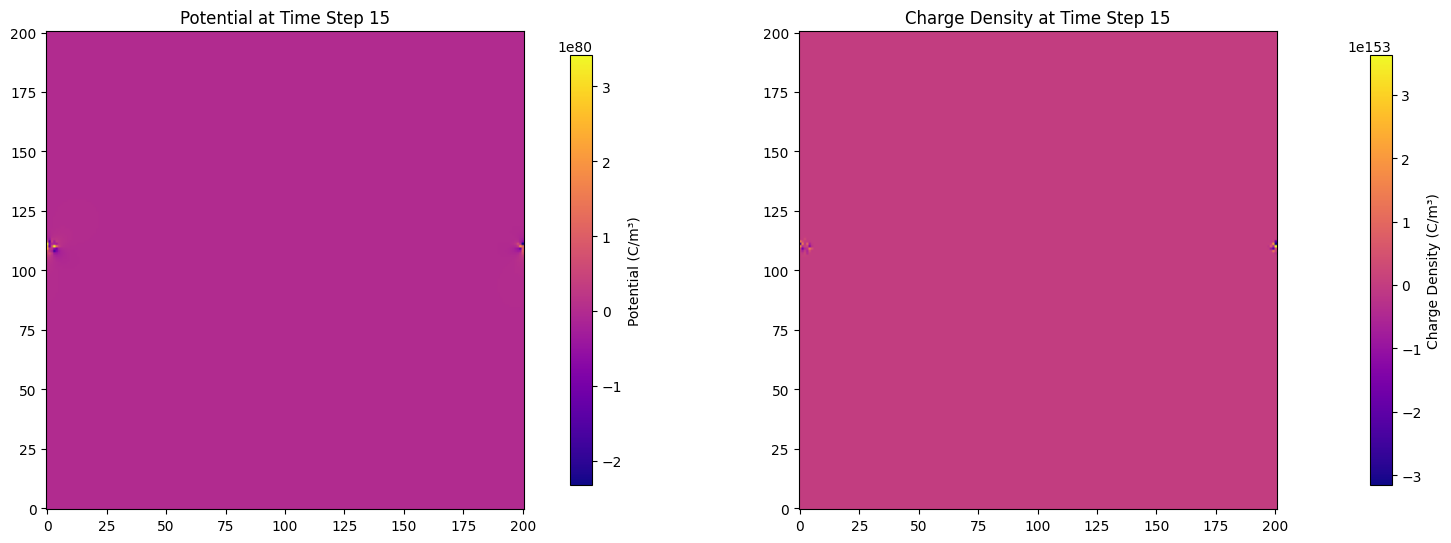

In [8]:
rho = np.zeros([nx+1,ny+1],float)

rho[90:111,:]= -1e13* (1.6e-19) 
rho[110,:] += 0.5e-10 *np.sin(0.0628*x)
rho[90,:] += 0.5e-10 *np.sin(0.0628*x)

dt = 1e-6
history = []
file_save = {}
frame_interval = 5
time_intervals = np.linspace(0, dt, 1)

plt.imshow(rho, origin = 'lower')
plt.colorbar()


step = 20
for i in range (step):
    
    phi = solve_poisson_1(rho)
    Ex, Ey = electric_field(phi)
    vx, vy = velocity(Ex, Ey, B)
    rho_new = solve_continuity(rho,vx,vy,dt)

    rho =  rho_new
    #rho = np.sum(rho_new)

    #Google how to save data in Python
    if i % frame_interval == 0:
        print(f"Time step {i}")
        print(f"Total charge = {np.sum(rho)}")
        history.append((rho.copy(), phi.copy(),i))
        file_save[f"time_step_{i}"] = (rho.copy(), phi.copy())
        np.savez('cylinder_test_1.npz', **file_save)

print("Simulation saved.")
rho_initial, phi_initial,i = history[0]

fig = plt.figure(figsize=(19, 6))
ax1 = fig.add_subplot(1, 1, 1)
plot_1 = ax1.imshow(rho_initial, origin = 'lower',cmap = 'plasma')
plot_1_tiltle = ax1.set_title(f"Charge Density at Time Step {i}")
fig.colorbar(plot_1, ax=ax1, label='Charge Density (C/m³)', shrink=0.9)
        
ax2 = fig.add_subplot(1, 2, 1)
plot_2 = ax2.imshow(phi_initial, origin = 'lower',cmap = 'plasma')
plot_2_tiltle = ax2.set_title(f"Potential at Time Step {i}")
fig.colorbar(plot_2, ax=ax2, label='Potential (C/m³)', shrink=0.9)
        #ax2.streamplot(X, Y, Ex, Ey, color="white", linewidth=1, cmap=plt.cm.inferno,
         #     density=1.5, arrowstyle='->', arrowsize=1.5)

#plt.show()
plt.tight_layout()

#Google how to animate in Python
def update(frame):
    rho_data, phi_data, step_num = history[frame]
    #scatter.set_offsets(np.vstack((nx, ny)).T)
    plot_1.set_data(rho_data)
    plot_2.set_data(phi_data)
    plot_1.set_clim(np.min(rho_data), np.max(rho_data))
    plot_2.set_clim(np.min(phi_data), np.max(phi_data))
    plot_1_tiltle.set_text((f"Charge Density at Time Step {step_num}"))
    plot_2_tiltle.set_text((f"Potential at Time Step {step_num}"))

    return plot_1, plot_2

ani = FuncAnimation(fig, update, frames=len(history), blit=True, interval=frame_interval)
print("Saving animation... This may take a moment.")
ani.save('cylinder_test_1.gif', writer='imagemagick', fps=15)

plt.show()

